In [25]:
from sklearn.datasets import load_sample_images
import numpy as np
import torch

sample_images = np.stack(load_sample_images()["images"])
sample_images = torch.tensor(sample_images , dtype=torch.float32) / 255 
sample_images_permuted = sample_images.permute(0 , 3 , 1 , 2) #Pytorch expects the channel dimension before the width and the Length 


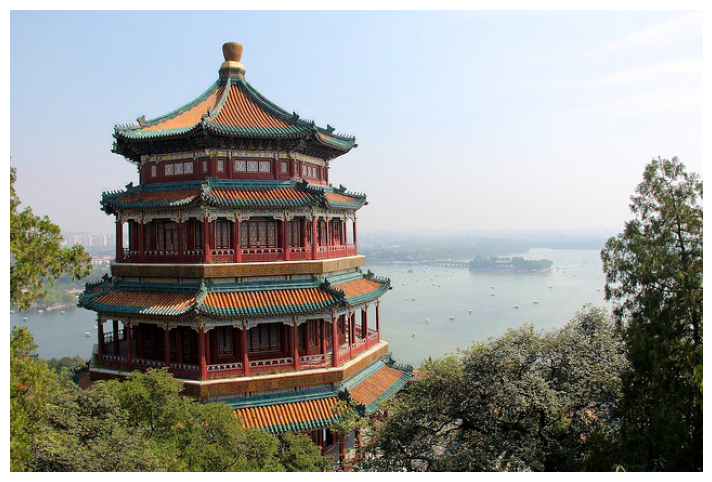

In [26]:
import matplotlib.pyplot as plt
Images = load_sample_images()
chinese_temple = Images.images
plt.figure(figsize=(10 , 6))
plt.imshow(chinese_temple[0])
plt.axis("off")
plt.show()

In [27]:
import torchvision
import torchvision.transforms.v2 as T 
centered_image = T.CenterCrop((70 , 120))(sample_images_permuted)

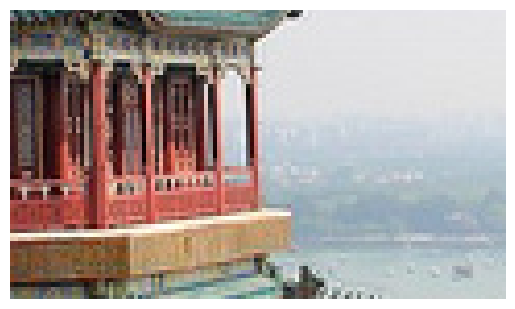

In [28]:
import matplotlib.pyplot as plt

image_to_show = np.transpose(centered_image[0], (1, 2, 0))
plt.imshow(image_to_show)
plt.axis('off')
plt.show()

In [29]:
import torch.nn as nn 

torch.manual_seed(42)
conv_model  = nn.Conv2d(in_channels= 3 , out_channels=32 , kernel_size=7 , padding="same") #32 Filters
fmaps = conv_model(centered_image)

print(f"The Input image shape : {centered_image.shape} and OUtput image shape {fmaps.shape}")

The Input image shape : torch.Size([2, 3, 70, 120]) and OUtput image shape torch.Size([2, 32, 70, 120])


In [30]:
#Pooling Layer
max_pool = nn.MaxPool2d(kernel_size=2) #Strides is equal to the kernel size

In [31]:
from sklearn.datasets import fetch_openml

fashion_mnist = fetch_openml(name="Fashion-MNIST" , as_frame= False)
targets = fashion_mnist.target.astype(int)

In [32]:
#Train_test split
from sklearn.model_selection import train_test_split

x_train , x_test = fashion_mnist.data[:60000] , fashion_mnist.data[60000:]
y_train , y_test = targets[:60000] , targets[60000:]

x_train , x_valid , y_train , y_valid = train_test_split(x_train , y_train , random_state=42)


In [33]:
import torch

x_train = torch.FloatTensor(x_train.reshape(-1 , 1 , 28 , 28))
x_test = torch.FloatTensor(x_test.reshape(-1 , 1 , 28 , 28))
x_valid = torch.FloatTensor(x_valid.reshape(-1 , 1 , 28 , 28))

In [34]:
means = x_train.mean(dim= 0 , keepdim=True)
std = x_train.std(dim= 0 , keepdim=True)
x_train = (x_train - means) / std
x_test = (x_test - means) / std
x_valid = (x_valid - means) / std

In [35]:
y_train = torch.LongTensor(y_train.reshape(-1 , 1))
y_test = torch.LongTensor(y_test.reshape(-1 , 1))
y_valid = torch.LongTensor(y_valid.reshape(-1 , 1))

In [36]:
import torch.nn as nn
from functools import partial
from torch.utils.data import TensorDataset , DataLoader

train_tesnor = TensorDataset(x_train , y_train)
train_data_loader = DataLoader(train_tesnor , batch_size= 32 , shuffle=True , pin_memory=True)

torch.manual_seed(42)
defaultConv2d = partial(nn.Conv2d , kernel_size = 3 , padding = "same")
model = nn.Sequential( 
    defaultConv2d(in_channels=1, out_channels=64, kernel_size=7), nn.ReLU(), 
    nn.MaxPool2d(kernel_size=2), 
    defaultConv2d(in_channels=64, out_channels=128), nn.ReLU(), 
    defaultConv2d(in_channels=128, out_channels=128), nn.ReLU(), 
    nn.MaxPool2d(kernel_size=2), 
    defaultConv2d(in_channels=128, out_channels=256), nn.ReLU(), 
    defaultConv2d(in_channels=256, out_channels=256), nn.ReLU(), 
    nn.MaxPool2d(kernel_size=2), 
    nn.Flatten(), 
    nn.Linear(in_features=2304, out_features=128), nn.ReLU(), 
    nn.Dropout(0.5), 
    nn.Linear(in_features=128, out_features=64), nn.ReLU(), 
    nn.Dropout(0.5), 
    nn.Linear(in_features=64, out_features=10),
).to(device = "cuda")

learning_rate = 0.01
epochs = 20
optimizer = torch.optim.SGD(model.parameters() , lr=learning_rate)
criterin = nn.CrossEntropyLoss()

In [38]:
def train(model , criterion , train_data_loader , optimizer , n_epochs):
    model.train()
    for epoch in range(n_epochs):
        total_loss = 0.0
        for x_batch , y_batch in train_data_loader:
            x_batch , y_batch = x_batch.to(device = "cuda") , y_batch.to(device = "cuda").squeeze(1)
            y_pred = model(x_batch)
            loss = criterion(y_pred , y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        mean_loss = total_loss / len(train_data_loader)
        print(f"Epoch {epoch +1} / {n_epochs} , loss:{mean_loss:.4f}")

train(model , criterin , train_data_loader , optimizer , epochs)

Epoch 1 / 20 , loss:0.3446
Epoch 2 / 20 , loss:0.3373
Epoch 3 / 20 , loss:0.3291
Epoch 4 / 20 , loss:0.3187
Epoch 5 / 20 , loss:0.3116
Epoch 6 / 20 , loss:0.3041
Epoch 7 / 20 , loss:0.2990
Epoch 8 / 20 , loss:0.2902
Epoch 9 / 20 , loss:0.2826
Epoch 10 / 20 , loss:0.2704
Epoch 11 / 20 , loss:0.2683
Epoch 12 / 20 , loss:0.2606
Epoch 13 / 20 , loss:0.2525
Epoch 14 / 20 , loss:0.2472
Epoch 15 / 20 , loss:0.2428
Epoch 16 / 20 , loss:0.2356
Epoch 17 / 20 , loss:0.2369
Epoch 18 / 20 , loss:0.2290
Epoch 19 / 20 , loss:0.2174
Epoch 20 / 20 , loss:0.2148


In [ ]:
def evaluate(model , train_data_loader , metrics_fn , aggregate_fn = lambda metric : torch.mean(metric)):
    model.eval()
    metrics = []
    with torch.no_grad():
        for x_batch , y_batch in train_data_loader:
            x_batch , y_batch = x_batch.to(device = "cuda") , y_batch.to(device = "cuda").squeeze(1)
            y_pred = model(x_batch)
            metric = metrics_fn(y_pred , y_batch)
            metrics.append(metric)
        metrics = torch.stack(metrics)
        return aggregate_fn(metrics)

valid_tensor = TensorDataset(x_valid , y_valid)
valid_dataset = DataLoader(valid_tensor , batch_size=32 , shuffle=True , pin_memory=True)
train_loss = evaluate(model , train_data_loader, criterin )
valid_data_loss = evaluate(model , valid_dataset , criterin)
print(f"The difference between  value in training set and valid set is { - train_loss + valid_data_loss}")

The difference between rmse value in training set and valid set is -0.14174489676952362


In [47]:
def accuracy_metric(y_pred, y_batch):
    _, predicted = torch.max(y_pred, 1)
    correct = (predicted == y_batch).float()
    return torch.mean(correct)

train_accuracy = evaluate(model , train_data_loader, accuracy_metric)
print(f"The accuracy is {train_accuracy}")
#Test Data Accuracy 
test_tensor = TensorDataset(x_test , y_test)
test_data_loader = DataLoader(test_tensor , batch_size=32 , shuffle=True , pin_memory=True)
test_accuracy = evaluate(model , test_data_loader , accuracy_metric)
print(f"The test-data accuracy is {test_accuracy}")

The accuracy is 0.9381219148635864
The test-data accuracy is 0.9002595543861389
